In [1]:
import pandas as pd
import numpy as np
from rdkit.Chem import PandasTools

df = pd.read_csv('/Users/francisco/Library/CloudStorage/OneDrive-Pessoal/Documentos/LabMol/DOUTORADO/SWE/BINDING_DB/DB_curada.csv', sep=';')
PandasTools.AddMoleculeColumnToFrame(frame=df, smilesCol='SMILES_curated')

In [2]:
from rdkit.Chem import AllChem

def morgan_fp(mol):
   morgan = AllChem.GetMorganGenerator(radius=2, fpSize=1024)
   return morgan.GetFingerprint(mol)

df['morgan'] = df['ROMol'].apply(morgan_fp)

In [3]:
from rdkit import DataStructs

def matrix_Tanimoto(mols):
   matrix = []
   
   for mol in mols:
       array_similaridade = DataStructs.BulkTanimotoSimilarity(mol, mols)
       matrix.append(array_similaridade)

   return pd.DataFrame(data=matrix)

tanimoto = matrix_Tanimoto(df['morgan'])
tanimoto

,0,1,2,3,4,5,6,7,8,9,...,1027,1028,1029,1030,1031,1032,1033,1034,1035,1036
0,1.000000,0.230769,0.207317,0.191919,0.212766,0.258427,0.228261,0.228261,0.189474,0.252874,...,0.165049,0.166667,0.148936,0.212500,0.219512,0.243243,0.197531,0.168317,0.170000,0.178218
1,0.230769,1.000000,0.305882,0.428571,0.726027,0.458824,0.453488,0.453488,0.543210,0.512500,...,0.346939,0.284314,0.176471,0.184783,0.217391,0.223529,0.172043,0.354167,0.372340,0.350515
2,0.207317,0.305882,1.000000,0.206186,0.255556,0.219780,0.272727,0.272727,0.230769,0.350000,...,0.166667,0.168317,0.407895,0.129412,0.125000,0.213333,0.129412,0.170000,0.171717,0.168317
3,0.191919,0.428571,0.206186,1.000000,0.466667,0.688312,0.597561,0.597561,0.637500,0.530120,...,0.393939,0.304762,0.135135,0.185567,0.204082,0.157895,0.138614,0.431579,0.391753,0.383838
4,0.212766,0.726027,0.255556,0.466667,1.000000,0.500000,0.511905,0.511905,0.587500,0.684932,...,0.381443,0.266667,0.173077,0.206522,0.252747,0.191011,0.193548,0.404255,0.488636,0.511364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1032,0.243243,0.223529,0.213333,0.157895,0.191011,0.168539,0.179775,0.179775,0.179775,0.188235,...,0.166667,0.168421,0.176471,0.328358,0.210526,1.000000,0.186667,0.170213,0.184783,0.180851
1033,0.197531,0.172043,0.129412,0.138614,0.193548,0.147368,0.145833,0.145833,0.122449,0.191011,...,0.135922,0.171717,0.093750,0.205128,0.154762,0.186667,1.000000,0.161616,0.187500,0.183673
1034,0.168317,0.354167,0.170000,0.431579,0.404255,0.382979,0.393617,0.393617,0.393617,0.443182,...,0.840000,0.574713,0.223301,0.185567,0.204082,0.170213,0.161616,1.000000,0.687500,0.670732
1035,0.170000,0.372340,0.171717,0.391753,0.488636,0.387097,0.397849,0.397849,0.382979,0.482353,...,0.802632,0.494505,0.237624,0.225806,0.244681,0.184783,0.187500,0.687500,1.000000,0.942857


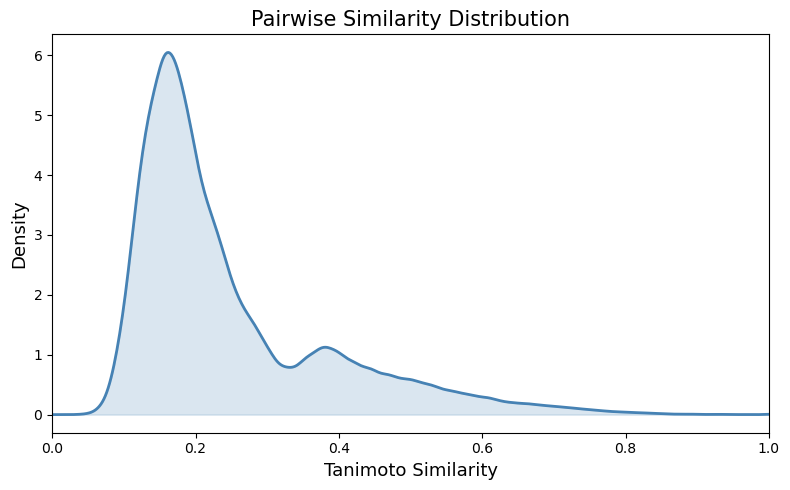

In [4]:

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# Extract upper triangle (excluding diagonal) to avoid duplicates and self-similarity
similarities = tanimoto.values[np.triu_indices_from(tanimoto.values, k=1)]

x = np.linspace(0, 1, 500)
kde = gaussian_kde(similarities, bw_method=0.05)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(x, kde(x), color='steelblue', linewidth=2)
ax.fill_between(x, kde(x), alpha=0.2, color='steelblue')

ax.set_xlabel('Tanimoto Similarity', fontsize=13)
ax.set_ylabel('Density', fontsize=13)
ax.set_title('Pairwise Similarity Distribution', fontsize=15)
ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()


In [25]:
threshold = 0.6

from rdkit.ML.Cluster import Butina

def butina(fingerprints):
   matrix = []

   for i in range(len(fingerprints)):
       for j in range(i):
           similaridade = DataStructs.TanimotoSimilarity(fingerprints[i], fingerprints[j])
           matrix.append(1 - similaridade)

   clusters = Butina.ClusterData(data=matrix, nPts=len(fingerprints), distThresh=threshold, isDistData=True)
   clusters = sorted(clusters, key=len, reverse=True)

   return clusters

clusters = butina(df['morgan'])

In [26]:
df['cluster'] = np.nan
for indice in range(len(clusters)):
   for registro in clusters[indice]:
       df.loc[registro, 'cluster'] = indice

print(f'Number of clusters: {len(clusters)}')

Number of clusters: 41


In [27]:

from sklearn.manifold import TSNE
from bokeh.plotting import figure, show, output_notebook
from bokeh.models import ColumnDataSource, HoverTool
from bokeh.palettes import turbo
from rdkit.Chem import Draw, MolFromSmiles
from io import BytesIO
import base64
import numpy as np

output_notebook()

# Convert fingerprints to numpy array
fp_array = np.array([list(fp) for fp in df['morgan']])

# t-SNE 2D reduction
tsne = TSNE(n_components=2, random_state=42, perplexity=50, max_iter=500)
coords = tsne.fit_transform(fp_array)

plot_df = df[['ID_Control', 'SMILES_curated', 'IC50 (nM)', 'cluster']].copy()
plot_df['t-SNE 1'] = coords[:, 0]
plot_df['t-SNE 2'] = coords[:, 1]
plot_df['cluster'] = plot_df['cluster'].fillna(-1).astype(int).astype(str)
plot_df['cluster'] = plot_df['cluster'].replace('-1', 'Singleton')

# Generate base64 molecule images for hover tooltip
def mol_to_base64(smiles):
    mol = MolFromSmiles(smiles)
    if mol is None:
        return ""
    img = Draw.MolToImage(mol, size=(200, 150))
    buf = BytesIO()
    img.save(buf, format='PNG')
    return "data:image/png;base64," + base64.b64encode(buf.getvalue()).decode()

plot_df['img'] = plot_df['SMILES_curated'].apply(mol_to_base64)

# Assign colors per cluster
clusters_list = sorted(plot_df['cluster'].unique(), key=lambda x: (x == 'Singleton', x if x != 'Singleton' else ''))
palette = turbo(max(3, len(clusters_list)))
color_map = {c: palette[i % len(palette)] for i, c in enumerate(clusters_list)}
plot_df['color'] = plot_df['cluster'].map(color_map)

source = ColumnDataSource(plot_df)

hover = HoverTool(tooltips="""
<div style="padding:4px; background:#fff; border:1px solid #ccc; border-radius:4px;">
    <img src="@img" style="width:200px; height:150px; display:block; margin-bottom:4px;"/>
    <b>ID:</b> @ID_Control<br>
    <b>IC50:</b> @{IC50 (nM)} nM<br>
    <b>Cluster:</b> @cluster<br>
    <b>SMILES:</b> <span style="font-size:10px;">@SMILES_curated</span>
</div>
""")

p = figure(
    width=900, height=650,
    title='Chemical Space – Butina Clusters (t-SNE)',
    tools=[hover, 'pan', 'wheel_zoom', 'box_zoom', 'reset', 'save'],
)

p.scatter('t-SNE 1', 't-SNE 2', source=source,
          color='color', size=6, alpha=0.75, line_color=None)

p.xaxis.axis_label = 't-SNE 1'
p.yaxis.axis_label = 't-SNE 2'
p.title.text_font_size = '14pt'

show(p)


Loading BokehJS ...

In [28]:

# O primeiro índice de cada cluster Butina é o centroide
centroids_idx = [cluster[0] for cluster in clusters]

df_centroids = df.iloc[centroids_idx][['ID_Control', 'SMILES_curated', 'IC50 (nM)', 'cluster']].reset_index(drop=True)

print(f'{len(df_centroids)} centroids extracted.')
df_centroids

41 centroids extracted.


,ID_Control,SMILES_curated,IC50 (nM),cluster
0,ID_031,CCn1c(CO)nn(-c2cc(O[C@@H](C)C(F)(F)F)c(C(=O)Nc...,3.000000,0.0
1,ID_866,CCn1c(CO)nn(-c2nc3c(C(C)C)cn(-c4ccccc4C)c(=O)c...,0.623000,1.0
2,ID_986,Cc1ccccc1NC(=O)c1cc(F)c(-c2nc([C@@H](C)O)n(C)n...,2.050000,2.0
3,ID_136,Cc1nc2c(C(=O)O)cc(-c3c(F)c(F)c(-c4ccccc4)c(F)c...,5.500000,3.0
4,ID_103,Cc1ccc(Nc2cnc(-c3ccccc3F)c(C)c2)c(C(=O)O)c1,5.000000,4.0
5,ID_1000,O=C(Nc1c(F)c(F)c(-c2cccc(OC(F)(F)F)c2)c(F)c1F)...,2.300000,5.0
6,ID_189,Cc1c(-c2ccc(-c3ccccc3)cc2)nc2ccc(F)cc2c1C(=O)O,7.000000,6.0
7,ID_286,COc1cccc(-c2cc(F)c(Nc3ncc(C)cc3C(=O)O)c(F)c2)c1,12.000000,7.0
8,ID_930,Cc1ccccc1-n1ncc2c1CCC[C@H]2NC(=O)c1noc2c1CCCC2,1.200000,8.0
9,ID_240,Cc1cccnc1NC(=O)c1cc(F)c(-n2nc3n(c2=O)CCCC3)cc1...,9.500000,9.0


In [30]:
df_centroids.to_csv('/Users/francisco/Library/CloudStorage/OneDrive-Pessoal/Documentos/LabMol/DOUTORADO/SWE/BINDING_DB/centroids_41_ts0_6.csv', index=False)